# Tutorial 04: Probabilistic Bayesian Regression & Conformal Safety

### Learning Objectives
1. Understand the difference between Aleatoric noise and Epistemic model ignorance.
2. Derive the closed-form Gaussian posterior $p(w \mid X, y) = \mathcal{N}(m_N, S_N)$.
3. Sample credible regression parameter hypotheses via Cholesky decomposition.
4. Guarantee distribution-free finite-sample coverage via Split Conformal Prediction:
   $$P(y \in [\hat{y} - \hat{q}, \hat{y} + \hat{q}]) \ge 1 - \alpha$$

In [1]:
import sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

# Robust import setup: traverse up until 'src' directory is found
root_dir = Path.cwd().resolve()
while not (root_dir / "src").exists() and root_dir != root_dir.parent:
    root_dir = root_dir.parent
if str(root_dir) not in sys.path:
    sys.path.insert(0, str(root_dir))

from src.bayesian import BayesianLinearRegression
from src.conformal import ConformalLinearRegression
from src.solvers import ClosedFormLinearRegression

## 1. Fitting Bayesian Linear Regression & Epistemic Decomposition

In [2]:
np.random.seed(42)
N = 100
X = np.random.uniform(-2, 2, size=(N, 1))
y = 2.0 * X[:, 0] + 0.5 + np.random.normal(0, 0.2, size=N)

bayes = BayesianLinearRegression(alpha=1.0, beta=25.0)
bayes.fit(X, y)

# Query range including out-of-distribution extrapolation (x in [-4, 4])
X_query = np.linspace(-4.5, 4.5, 200).reshape(-1, 1)
y_mean, y_std = bayes.predict(X_query, return_std=True)

print(f"Posterior Mean: w={bayes.weights[0]:.4f}, b={bayes.bias:.4f}")
print(f"In-distribution std (at x=0):  {bayes.predict(np.array([[0.0]]), return_std=True)[1][0]:.4f}")
print(f"Out-of-distribution std (x=4): {bayes.predict(np.array([[4.0]]), return_std=True)[1][0]:.4f}")

Posterior Mean: w=1.9764, b=0.4970
In-distribution std (at x=0):  0.2000
Out-of-distribution std (x=4): 0.2118


## 2. Visualizing Bayesian Credible Bands & Posterior Weight Sampling

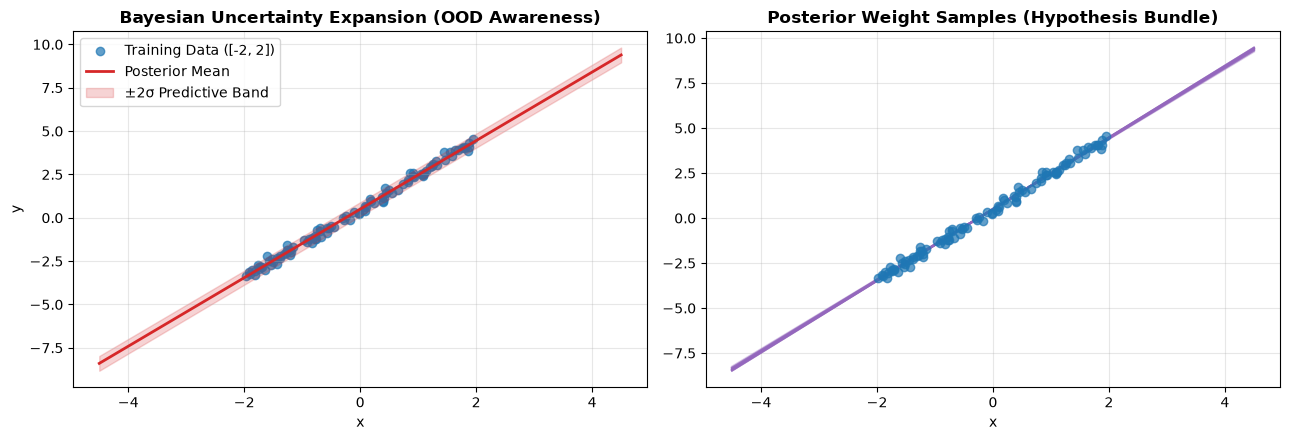

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Plot 1: Predictive Mean + 2-Sigma Uncertainty Envelope
axes[0].scatter(X, y, color="tab:blue", alpha=0.7, label="Training Data ([-2, 2])")
axes[0].plot(X_query, y_mean, color="tab:red", lw=2, label="Posterior Mean")
axes[0].fill_between(
    X_query[:, 0],
    y_mean - 2 * y_std,
    y_mean + 2 * y_std,
    color="tab:red",
    alpha=0.2,
    label="±2σ Predictive Band"
)
axes[0].set_title("Bayesian Uncertainty Expansion (OOD Awareness)", fontweight="bold")
axes[0].set_xlabel("x")
axes[0].set_ylabel("y")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2: Sampled Hypothesis Lines from Posterior
w_samples = bayes.sample_weights(n_samples=20, random_state=42)
for i in range(20):
    axes[1].plot(X_query, X_query @ w_samples[i] + bayes.bias, color="tab:purple", alpha=0.35)

axes[1].scatter(X, y, color="tab:blue", alpha=0.7, zorder=5)
axes[1].set_title("Posterior Weight Samples (Hypothesis Bundle)", fontweight="bold")
axes[1].set_xlabel("x")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 3. Conformal Prediction with Guaranteed Finite-Sample Coverage
Conformal prediction calibration produces exact coverage bounds without assuming Gaussianity.

In [4]:
base_est = ClosedFormLinearRegression(method="svd")
conformal = ConformalLinearRegression(estimator=base_est, alpha=0.10, cal_size=0.25, random_state=42)
conformal.fit(X, y)

# Generate test split
X_test = np.random.uniform(-2, 2, size=(200, 1))
y_test = 2.0 * X_test[:, 0] + 0.5 + np.random.normal(0, 0.2, size=200)

cov_score = conformal.score_coverage(X_test, y_test)
print(f"Nominal Confidence Level: 90.00%")
print(f"Calibrated Cutoff q_hat:    {conformal.q_hat_:.4f}")
print(f"Empirical Test Coverage:   {cov_score * 100:.2f}%")

Nominal Confidence Level: 90.00%
Calibrated Cutoff q_hat:    0.4654
Empirical Test Coverage:   99.50%
